# The Covariance Matrix

Consider a set of observed data, for example the Iris dataset.

In [1]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

In [3]:
X = pd.DataFrame(X)

In [4]:
X.sample(5, random_state=10)

,0,1,2,3
87,6.3,2.3,4.4,1.3
111,6.4,2.7,5.3,1.9
10,5.4,3.7,1.5,0.2
91,6.1,3.0,4.6,1.4
49,5.0,3.3,1.4,0.2


If we center this matrix of observed values, that is subtract the mean of column from each column, then this represents how far off from the mean of the observed values, a given value was. 

In [6]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

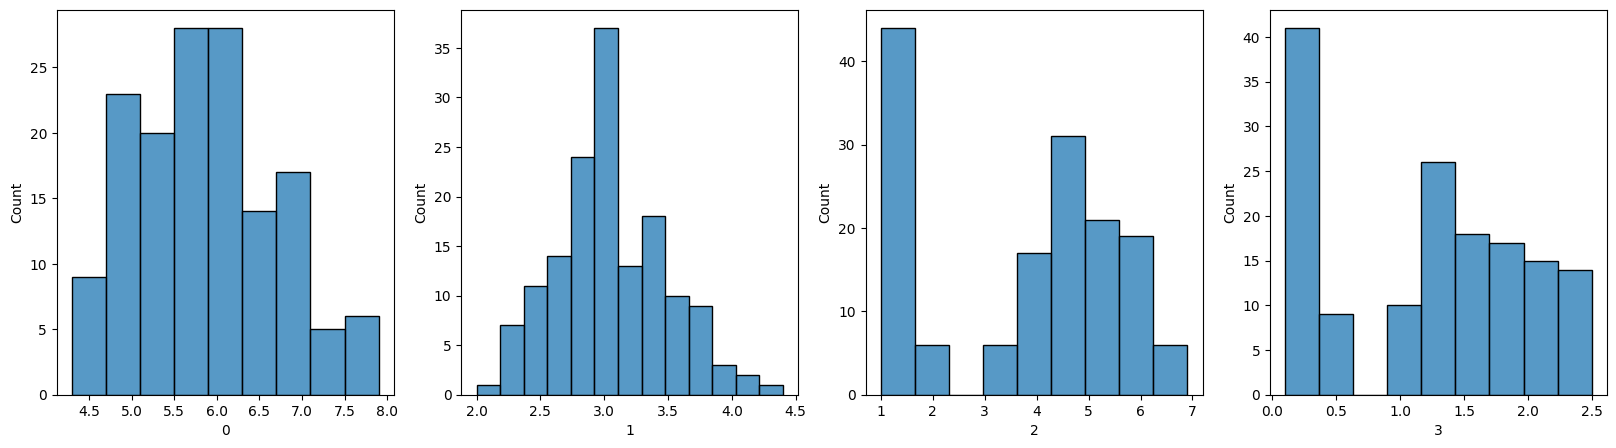

In [5]:
fig, ax = plt.subplots(1,4, figsize=(20,5))
for i, feature in enumerate(X.columns):
    sns.histplot(X[feature], ax=ax[i])

In [7]:
X_c = X - X.mean()

In [8]:
X.mean()

0    5.843333
1    3.057333
2    3.758000
3    1.199333
dtype: float64

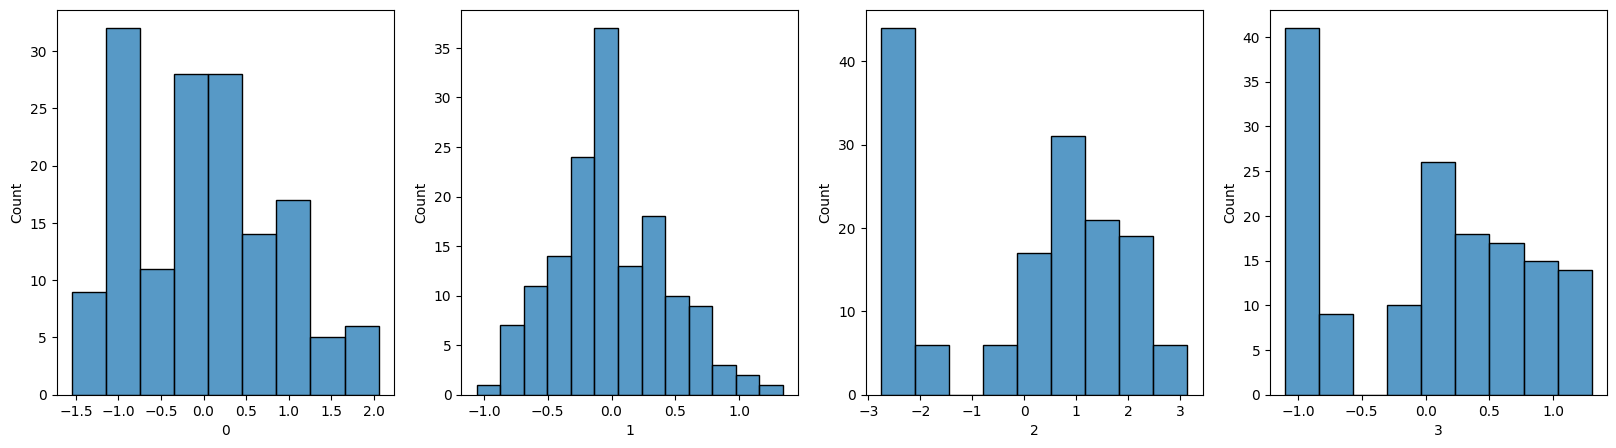

In [9]:
fig, ax = plt.subplots(1,4, figsize=(20,5))
for i, feature in enumerate(X_c.columns):
    sns.histplot(X_c[feature], ax=ax[i])

## Total Sum of Squares

The centered data is closely related to the TSS, the **total sum of squares**. 

https://en.wikipedia.org/wiki/Total_sum_of_squares

$$\text{TSS} = \sum (x_i -\bar{x})^2 = (\mathbf{x} - \mathbf{\bar{x}})^T(\mathbf{x} - \mathbf{\bar{x}})$$

for a given feature vector, $\mathbf{x}$.

Here, $\bar{x}$ represents the mean value of $\mathbf{x}$ and $\mathbf{\bar{x}}$ represents a vector of the same size as $\mathbf{x}$ with each element equal to $\bar{x}$.

In pure python:

In [10]:
xx = [1,2,3,4,5]
x_bar = sum(xx)/len(xx)

In [11]:
x_bar

3.0

In [12]:
x_c = [x_i - x_bar for x_i in xx]

In [13]:
x_c

[-2.0, -1.0, 0.0, 1.0, 2.0]

In [15]:
sum([(x_i - x_bar)**2 for x_i in xx])

10.0

In [14]:
TSS = sum([x_i*x_i for x_i in x_c])
TSS

10.0

If we perform these dot products on our centered data, we have the TSS for each feature.

In [18]:
xx_np = np.array(x_c)
TSS_np = xx_np.dot(xx_np)
TSS_np

np.float64(10.0)

In [19]:
TSS_0 = X_c[0].dot(X_c[0]) # sepal length
TSS_1 = X_c[1].dot(X_c[1]) # sepal width
TSS_2 = X_c[2].dot(X_c[2]) # petal length
TSS_3 = X_c[3].dot(X_c[3]) # petal width
TSS_0, TSS_1, TSS_2, TSS_3

(np.float64(102.16833333333335),
 np.float64(28.306933333333326),
 np.float64(464.32540000000006),
 np.float64(86.56993333333332))

## Variance

If we divide TSS by the number of items in the vector, we have the variance of feature.

In [20]:
n = X_c.shape[0]
n

150

In [22]:
var_0 = TSS_0/n
var_0, X_c[0].var(ddof=0)

(np.float64(0.6811222222222223), np.float64(0.6811222222222223))

In [23]:
var_1 = TSS_1/n
var_1, X_c[1].var(ddof=0)

(np.float64(0.18871288888888885), np.float64(0.1887128888888889))

In [24]:
X_c[1].var()

np.float64(0.189979418344519)

Note that we had to specify a `ddof` of 0. The default is a `ddof` of 1, corresponding to a scaling by `n-1`, that is the [sample correction](https://en.wikipedia.org/wiki/Bessel%27s_correction).

In [25]:
var_0 = TSS_0/(n-1)
var_0, X_c[0].var()

(np.float64(0.6856935123042507), np.float64(0.6856935123042506))

In [26]:
var_1 = TSS_1/(n-1)
var_1, X_c[1].var()

(np.float64(0.18997941834451898), np.float64(0.189979418344519))

$$\text{TSS} = n\text{Var}(x) = n\sigma^2$$

## Covariance

We can find the covariance by multiplying two different centered features and dividing by the number of features.

This is available by the `pandas.DataFrame` argument `.cov()`. Note that by default, this is done using `n-1`.

In [27]:
X_c.cov()

,0,1,2,3
0,0.685694,-0.042434,1.274315,0.516271
1,-0.042434,0.189979,-0.329656,-0.121639
2,1.274315,-0.329656,3.116278,1.295609
3,0.516271,-0.121639,1.295609,0.581006


In [28]:
X_c[0].dot(X_c[1])/(n-1)

np.float64(-0.04243400447427293)

`pandas.DataFrame.cov()` return a **Covariance Matrix** consisting of the respective sample covariances between each feature. Note that the diagonal contains the variances, which is to say that the covariance between a feature and itself is the variance of that feature. 

## Interpretation in terms of Single Variable Regression

In [29]:
X_c.columns = iris.feature_names

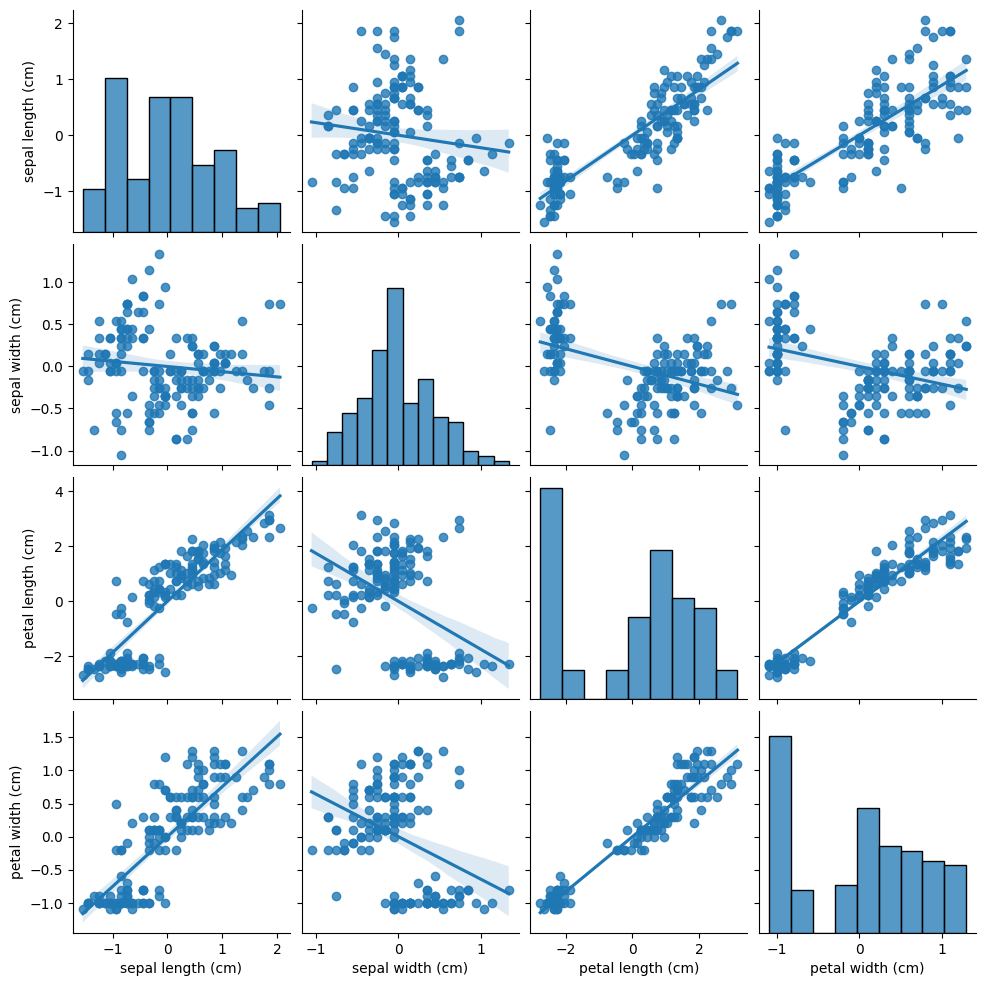

In [30]:
sns.pairplot(X_c, kind='reg')

In [31]:
X_c.cov()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.685694,-0.042434,1.274315,0.516271
sepal width (cm),-0.042434,0.189979,-0.329656,-0.121639
petal length (cm),1.274315,-0.329656,3.116278,1.295609
petal width (cm),0.516271,-0.121639,1.295609,0.581006


In [32]:
X.shape

(150, 4)

In [33]:
X.cov().shape

(4, 4)

In [34]:
X.cov()

,0,1,2,3
0,0.685694,-0.042434,1.274315,0.516271
1,-0.042434,0.189979,-0.329656,-0.121639
2,1.274315,-0.329656,3.116278,1.295609
3,0.516271,-0.121639,1.295609,0.581006
